In [1]:
import numpy as np
import utils
import control as ctrl
import matplotlib.pyplot as plt
import os

### 1)

Partimos del sistema aumentado de la parte A con un integrador para poder seguir una referencia $\psi_{ref}$:

\begin{align*}
  \dot{\mathbf{x}}_a &= \mathbf{A}_a\mathbf{x}_a + \mathbf{B}_a\tau_r + \mathbf{E}_a\psi_{ref}
\end{align*}

Donde:


$$\mathbf{A}_a = \begin{bmatrix}
  -0.25 & -2 & 0 & 0 \\
  0.08 & -0.35 & 0 & 0 \\
  0 & 1 & 0 & 0 \\
  0 & 0 & -1 & 0
\end{bmatrix}, \quad
\mathbf{B}_a = \begin{bmatrix} 0 \\ 0.62 \\ 0 \\ 0 \end{bmatrix}, \quad
\mathbf{E}_a = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix} $$



Para el diseño LQI, se busca una ley de control de la forma:

$$
\tau_{r}=-K_{a}x_{a}
$$

con:

$$
K_a=
\begin{bmatrix}
k_v & k_r & k_\psi & k_i
\end{bmatrix}
$$

Por lo tanto:

$$
\tau_r= -k_v v - k_r r - k_\psi \psi - k_i \xi
$$

El objetivo del diseño LQI es encontrar la ganancia $K_a$ que minimice la siguiente función de costo cuadrática:

$$
J=\int_0^\infty \left(x_a^T Q_a x_a + \tau_r^T R \tau_r \right)dt
$$

Como el sistema tiene una única entrada, $\tau_r$ es escalar, por lo que la función de costo también puede escribirse como:

$$
J=\int_0^\infty \left(x_a^T Q_a x_a + R\tau_r^2 \right)dt
$$

La matriz $Q_a$ penaliza los estados aumentados del sistema, mientras que $R$ penaliza el esfuerzo de control. Los pesos asociados a $\psi$ y a $xi$ permiten regular la precisión del seguimiento de rumbo y la eliminación del error estacionario, mientras que el valor de $R$ permite limitar la magnitud de la señal de control $\tau_r$.

Una elección posible para $Q_a$, si se trabaja con una matriz diagonal, es:

$$
Q_a=
\begin{bmatrix}
q_v & 0 & 0 & 0\\
0 & q_r & 0 & 0\\
0 & 0 & q_\psi & 0\\
0 & 0 & 0 & q_\xi
\end{bmatrix}
$$

y:

$$
R=
\begin{bmatrix}
r_u
\end{bmatrix}
$$


### 2)

PREGUNTAR PORQUE ES LO MISMO QUE PARTE A ejericio 4)

In [2]:
A = np.array([
    [-0.25, -2, 0],
    [0.08, -0.35, 0],
    [0, 1, 0]
])

B = np.array([
    [0],
    [0.62],
    [0]
])


C = np.array([[0, 0, 1]])

A_a = np.hstack([
    np.vstack([A, -C]), np.zeros((4, 1))
])

B_a = np.vstack([B, np.array([[0]])])

E_a = np.array([[0], [0], [0], [1]])

utils.check_controllability(A_a, B_a)

Matriz de controlabilidad:
[[ 0.        -1.24       0.744     -0.1395   ]
 [ 0.62      -0.217     -0.02325    0.0676575]
 [ 0.         0.62      -0.217     -0.02325  ]
 [ 0.         0.        -0.62       0.217    ]]

Rango de C: 4
Dimensión del sistema: 4

El sistema es controlable: True


Al calcular el rango de la matriz de controlabilidad se obtiene rango completo. Por lo tanto, el sistema aumentado es controlable.

Esto permite concluir que es posible diseñar un controlador LQI para el sistema aumentado, ya que la acción de control $\tau_r$ puede influir sobre todos los estados del modelo aumentado, incluyendo el estado integral $xi$. La incorporación del integrador permite eliminar el error estacionario frente a referencias constantes de rumbo.

### Diseño de controlador LQI

In [3]:
from src.parteC import LQI, get_info, plot_results, print_metrics

In [4]:
casos = {
    "AGRESIVO": {
        "Q_a": np.diag([1, 1, 50, 100]),
        "R": np.array([[1]])
    },
    "INTERMEDIO": {
        "Q_a": np.diag([1, 2, 30, 80]),
        "R": np.array([[10]])
    },
    "SUAVE": {
        "Q_a": np.diag([1, 5, 20, 50]),
        "R": np.array([[50]])
    }
}

Tf = 60
T = np.linspace(0, Tf, 3001)

psi_ref = np.zeros_like(T)
psi_ref[(T >= 10) & (T < 25)] = np.pi / 6
psi_ref[(T >= 25) & (T < 40)] = -np.pi / 6
psi_ref[(T >= 40) & (T <= 60)] = np.pi / 3

x0 = np.zeros(4)

results = {}

for name, params in casos.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    controller = LQI(params["Q_a"], params["R"], A_a, B_a, E_a, verbose=True)
    result = get_info(name, controller, T, psi_ref, x0)
    results[name] = result


AGRESIVO
K_a = [[  0.11013662   6.1203464   13.6645729  -10.        ]]
Polos LQI = [-1.43000924+1.66619895j -1.43000924-1.66619895j -1.28425664+0.j
 -0.25033966+0.j        ]

INTERMEDIO
K_a = [[ 0.1206056   3.46619819  5.11688483 -2.82842712]]
Polos LQI = [-0.7219319 +1.06663821j -0.7219319 -1.06663821j -0.25059663+0.j
 -1.05458244+0.j        ]

SUAVE
K_a = [[ 0.11968432  2.18981755  2.46134807 -1.        ]]
Polos LQI = [-0.47686276+0.76813255j -0.47686276-0.76813255j -0.25225098+0.j
 -0.75171037+0.j        ]


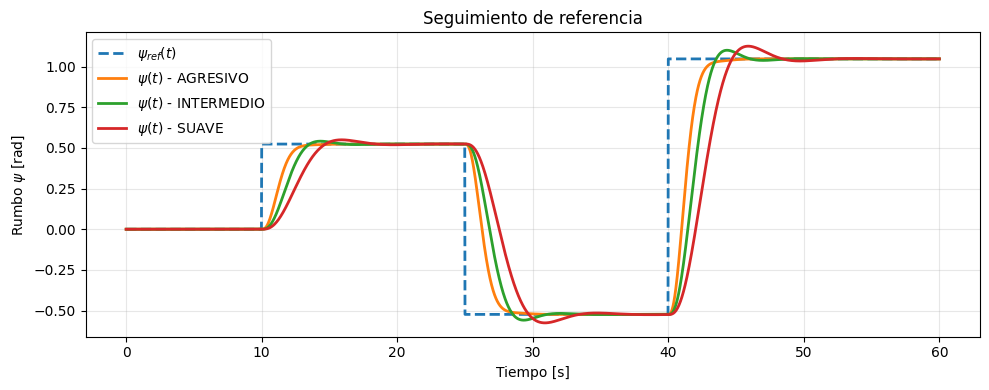

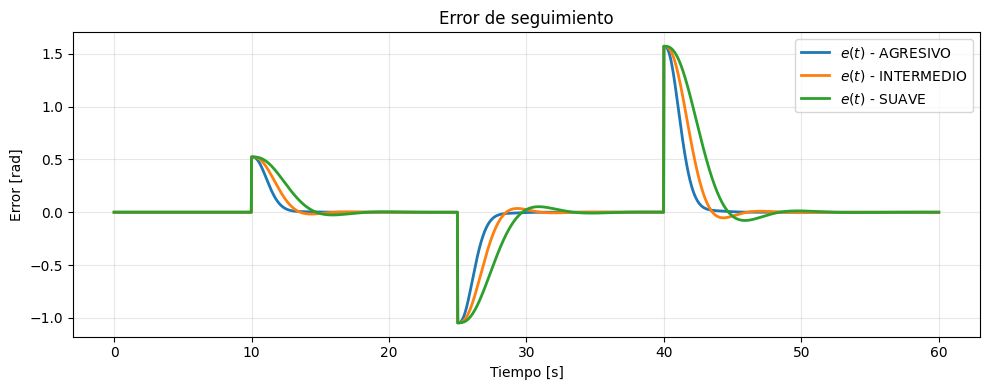

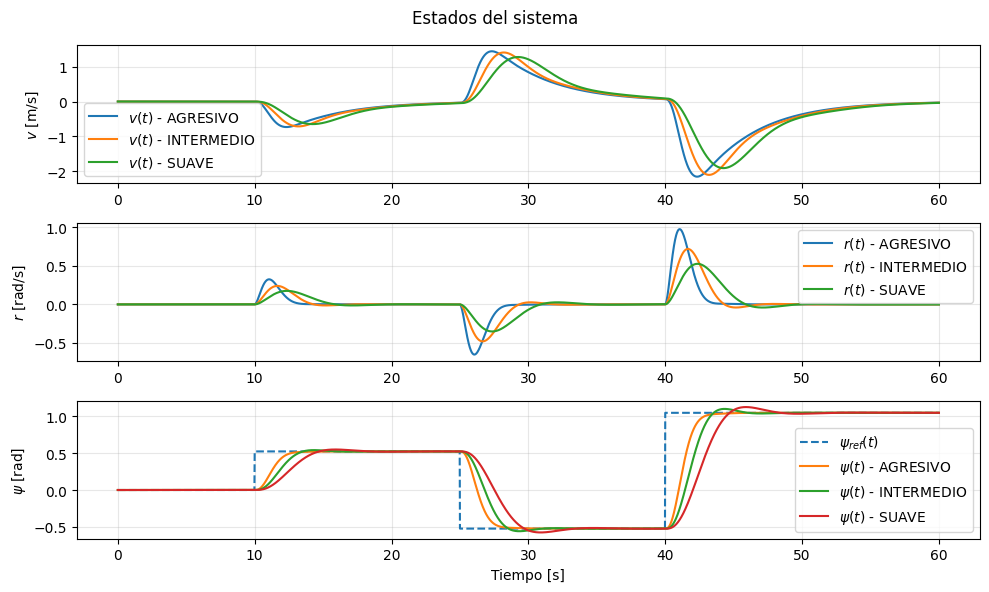

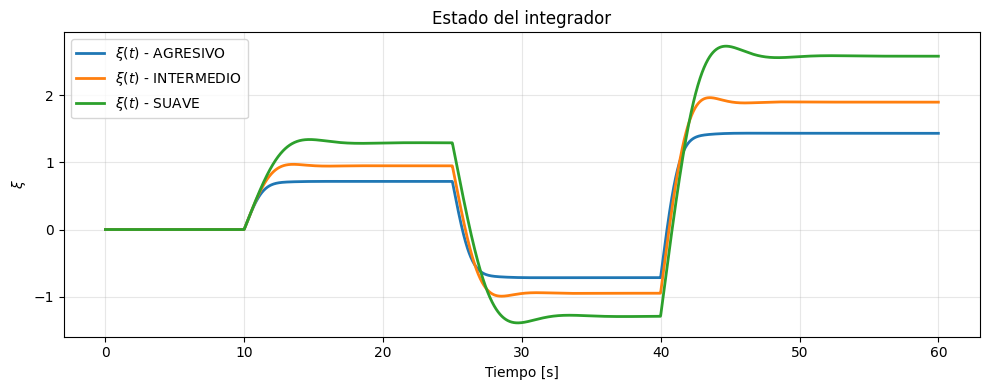

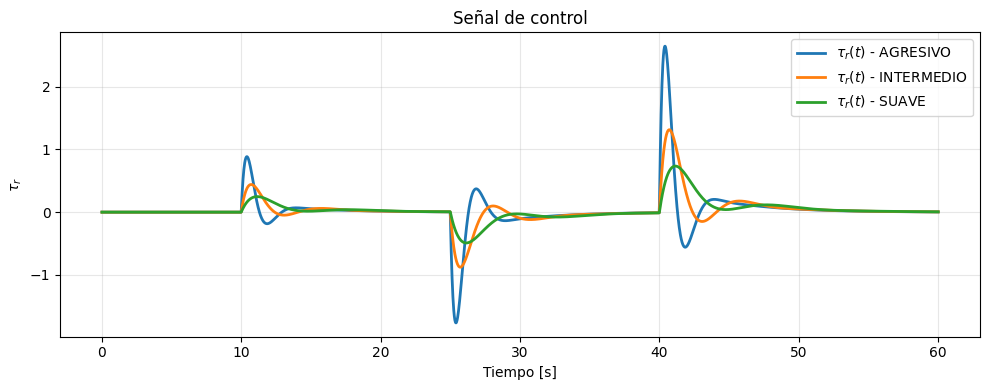

Controller        Max |tau_r|           RMS tau_r        Max |error|                IAE               ISE  Final error            Max |v|            Max |r|          Max |psi|
  AGRESIVO 2.6467768053993224  0.3396847286317828  1.570840280798321 4.3005536939967515  3.76563740394767    -0.000020  2.150256420074969 0.9749218954572986 1.0475131142612917
INTERMEDIO  1.314214493745893 0.22165480402841883 1.5708873601530078  6.013022749802872 5.416473704441984    -0.000038 2.0991414199072183 0.7184772709964362 1.1004181820461971
     SUAVE 0.7349084088120938 0.16034772749603562 1.5720319300911072   8.44845620742083 7.554348456883342    -0.000107 1.9057967387032266 0.5258611745826148 1.1255242006530104


,Controller,Max |tau_r|,RMS tau_r,Max |error|,IAE,ISE,Final error,Max |v|,Max |r|,Max |psi|
0,AGRESIVO,2.6467768053993224,0.3396847286317828,1.570840280798321,4.3005536939967515,3.76563740394767,-0.000020,2.150256420074969,0.9749218954572986,1.0475131142612917
1,INTERMEDIO,1.314214493745893,0.22165480402841883,1.5708873601530078,6.013022749802872,5.416473704441984,-0.000038,2.0991414199072183,0.7184772709964362,1.1004181820461971
2,SUAVE,0.7349084088120938,0.16034772749603562,1.5720319300911072,8.44845620742083,7.554348456883342,-0.000107,1.9057967387032266,0.5258611745826148,1.1255242006530104


In [5]:
plot_results(results, show=True, save=True, save_dir='plots')
print_metrics(results)